# Домашня робота 4 — Neural Architecture Search з Hyperopt (CNN / CIFAR-10)

**Курс:** Efficient ML, SET University

Neural Architecture Search (NAS) — це автоматичний пошук самої **архітектури** мережі,
а не її ваг. Замість того щоб вручну вгадувати «скільки шарів, які блоки, яка ширина»,
ми задаємо **дискретний простір** можливих архітектур і даємо оптимізатору знайти в
ньому найкращу. Тут оптимізатор — **TPE** (Tree-structured Parzen Estimator) з
[Hyperopt](https://github.com/hyperopt/hyperopt).

Головна проблема NAS — вартість: повноцінно натренувати кожну архітектуру з нуля надто
дорого. Рятує **weight sharing (one-shot)**: ми один раз тренуємо велику
**supernet**, чиї ваги спільні для всього простору, і оцінюємо будь-яку архітектуру
як її під-мережу — **без окремого навчання**. Це рівно та ідея slimmable-мереж, яку
ми вже застосували в бонусі ДЗ3 (NetAug), тільки тепер розширена на **вибір операції**
в кожній стадії.

### Що ми шукали (три осі, як вимагає умова)

| Вісь | Варіанти |
|---|---|
| **Операція блоку** (на кожну з 4 стадій) | `conv3x3` (звичайна згортка) · `dwsep` (depthwise-separable, MobileNet-v1) · `mbconv` (inverted residual, MobileNet-v2, expand ×3) |
| **Множник ширини** (глобальний) | 0.5 · 0.75 · 1.0 · 1.25 |
| **Активація** (глобальна) | ReLU · ReLU6 · SiLU · GELU · LeakyReLU |

Розмір простору = 3⁴ × 4 × 5 = **1620 архітектур**.

### Головний результат (тест — раз на фінальну модель)

| Модель | Параметри | Test acc |
|---|---|---|
| Baseline VGG11 (з ДЗ1) | 9.49M | 90.71% |
| In-space default (усі conv3x3, 1.0×, ReLU) | 0.96M | 90.26% |
| **Знайдена пошуком** (conv3x3/mbconv/conv3x3/mbconv, 1.0×, relu6) | **0.74M** | **90.69%** |

Знайдена архітектура дає **90.69%** — практично рівень baseline
(-0.02 п.п.) при **12.8× менше параметрів** (0.74M проти
9.49M), і на +0.43 п.п. краще за розумний default у тому ж
просторі. Тобто пошук знайшов набагато **компактнішу** мережу без втрати точності.

Наскільки надійним був one-shot proxy? Kendall τ = **0.11**, Spearman ρ =
**0.19** — тобто **грубо** proxy знаходить хороший регіон простору бездоганно
(усі топ-архітектури мають один мотив), але **тонко** ранжувати найкращих між собою
він майже не вміє. Деталі — у розділах 4–6 і у висновках.

## 1. Підготовка

In [1]:
import json
import torch
import matplotlib.pyplot as plt

from src.utils import get_device
from src.search_space import space_size, count_arch_params, StandaloneNet, sample_arch
from src import plots

RESULTS = "results"
def load(n):
    with open(f"{RESULTS}/{n}") as f: return json.load(f)
search   = load("search.json")
retrain  = load("retrain.json")
corr     = load("proxy_corr.json")
records  = search["records"]
print("device:", get_device(), "| простір:", space_size(), "архітектур")

device: cuda | простір: 1620 архітектур


## 2. Простір пошуку

Макро-скелет **фіксований**: 4 послідовні стадії, кожна = один шуканий блок + 2×2
max-pool (32→16→8→4→2 по просторовому розміру), потім global average pooling і
лінійний класифікатор. Пошук вирішує лише **що` за блок** у кожній стадії, **яку
ширину** й **яку активацію** — рівно три осі з умови.

Три операції — це класична «сходинка ефективності»:
- **`conv3x3`** — повна згортка 3×3: найвиразніша, найважча за параметрами;
- **`dwsep`** — depthwise 3×3 + pointwise 1×1: та сама форма, у рази менше параметрів;
- **`mbconv`** — inverted residual (expand→depthwise→project, +skip): компроміс, ядро
  сучасних мобільних мереж.

`src/search_space.py` також уміє побудувати будь-яку архітектуру як **звичайну**
(не-shared) мережу `StandaloneNet` — саме її ми потім тренуємо з нуля й саме на ній
рахуємо реальну кількість параметрів.

In [2]:
from src.search_space import OPS, WIDTHS, ACTS, count_arch_params
print("операції:", OPS)
print("ширини:  ", WIDTHS)
print("активації:", ACTS)
# приклад: та сама структура при різній ширині — різна кількість параметрів
for w in WIDTHS:
    a = {"ops": ["conv3x3","mbconv","conv3x3","mbconv"], "width": w, "act": "relu6"}
    print(f"  width {w}: {count_arch_params(a)/1e6:.2f}M параметрів")

операції: ['conv3x3', 'dwsep', 'mbconv']
ширини:   [0.5, 0.75, 1.0, 1.25]
активації: ['relu', 'relu6', 'silu', 'gelu', 'leakyrelu']
  width 0.5: 0.19M параметрів
  width 0.75: 0.42M параметрів
  width 1.0: 0.74M параметрів
  width 1.25: 1.16M параметрів


## 3. One-shot supernet + Single-Path One-Shot

Supernet зберігає ваги на **максимальній** ширині (1.25×) і тримає **всі три
операції** в кожній стадії як паралельні гілки. Під-мережа — це вибір однієї гілки
на стадію + зріз каналів `W[:out, :in]` спільної ваги. Тренуємо за схемою **SPOS**
(Guo et al., ECCV 2020): на кожному кроці семплимо **одну** випадкову архітектуру й
оновлюємо лише її шлях. За багато кроків усі операції/ширини/активації отримують
градієнти, і жоден шлях не має апріорної переваги.

Statistics BatchNorm у one-shot ненадійні (вони змішують усі ширини/операції, які
бачили під час тренування), тому **перед кожною оцінкою** ми **рекалібруємо** BN
активного шляху на кількох батчах — стандартна практика one-shot NAS.

Supernet тут — 2.61M параметрів (max ширина, усі операції),
тренували 100 епох. Крива нижче — середня точність випадкових
шляхів по епохах (не одна модель, а розподіл над шляхами — тож це грубий сигнал
«здоров'я» supernet, а не фінальна точність).

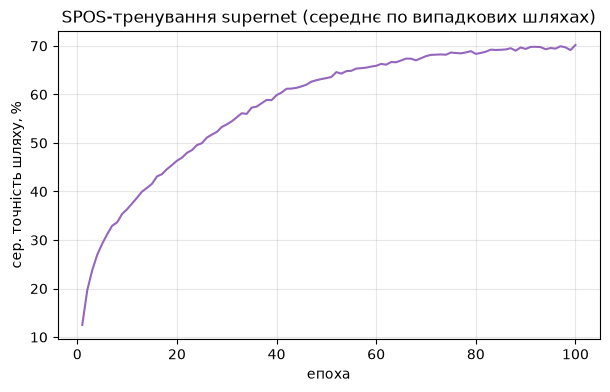

фінальна сер. точність шляху: 70.2%


In [3]:
h = search["supernet_history"]
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(range(1, len(h["train_acc"])+1), [a*100 for a in h["train_acc"]], color="tab:purple")
ax.set_xlabel("епоха"); ax.set_ylabel("сер. точність шляху, %")
ax.set_title("SPOS-тренування supernet (середнє по випадкових шляхах)")
ax.grid(alpha=0.3); plt.show()
print(f"фінальна сер. точність шляху: {h['train_acc'][-1]*100:.1f}%")

## 4. Пошук TPE (weight-sharing proxy)

TPE будує ймовірнісну модель «які конфігурації дають низький лос» і пропонує нові
кандидати, що максимізують очікуване покращення. Кожен trial коштує копійки: вибрати
під-шлях у натренованій supernet → рекалібрувати BN → порахувати **validation loss**.
Це proxy-оцінка; ми також фіксуємо кількість параметрів і proxy val-accuracy.

За 250 trial-ів TPE оцінив **139** унікальних архітектур (з
1620); решта 111 — повторні візити вже баченого (TPE
експлуатує вдалі зони — беремо їх з кешу).

**Два обов'язкові графіки:**

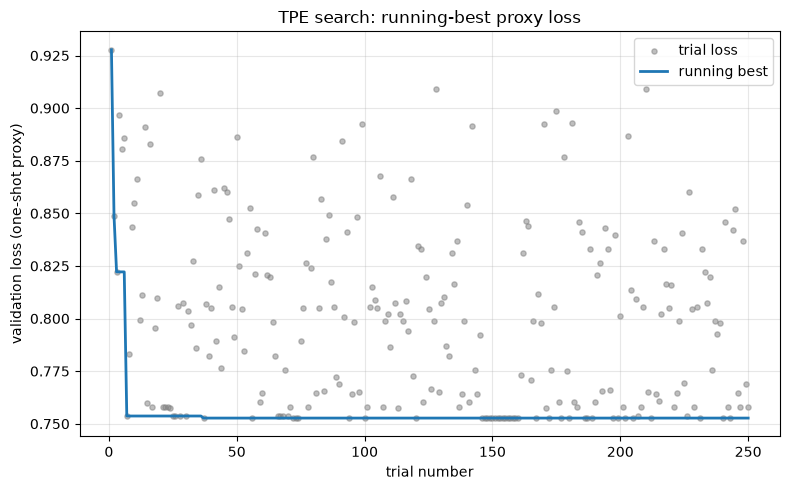

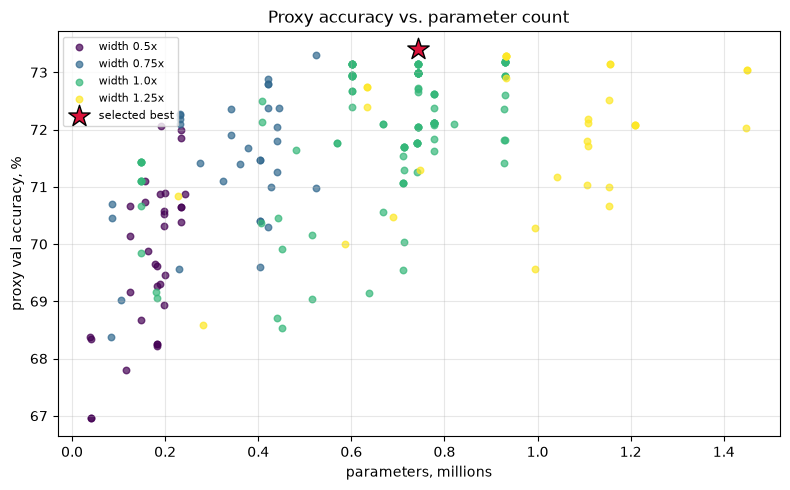

In [4]:
plots.plot_search_convergence(records); plt.show()
plots.plot_acc_vs_params(records, search["best_arch"]); plt.show()

**Що знайшов пошук.** Топ-архітектури за proxy напрочуд узгоджені — TPE збігся на
чіткий структурний мотив:

- **стадія 0 → `conv3x3`** (conv3x3×15): перший шар з «сирих» 3 каналів
  хоче повну згортку;
- **стадія 1 → `mbconv`** (mbconv×15): inverted residual у середині;
- стадія 2 → conv3x3×10, mbconv×5; стадія 3 → mbconv×10, conv3x3×5;
- ширина: 1.0×9, 1.25×4, 0.75×2 (ніколи 0.5× у топі); активація: relu6×7, relu×4, gelu×3, leakyrelu×1.

Найгірші архітектури — усі-`dwsep` при ширині 0.5× — падають до ~67% proxy-точності;
proxy впевнено відсіює їх. **Найкраща за proxy:** `conv3x3/mbconv/conv3x3/mbconv, 1.0×, relu6`, 0.74M,
proxy val-acc = 73.40%.

## 5. Retrain з нуля vs baseline

Proxy лише **ранжує**; фінальне число дає навчання обраної архітектури **з нуля** як
звичайної мережі (42-seed, 120 епох, cosine LR).
Порівнюємо з двома baseline: (1) заморожена VGG11 з ДЗ1 (той самий baseline через усі
ДЗ) і (2) **in-space default** (усі `conv3x3`, 1.0×, ReLU) з ідентичним рецептом — щоб
приписати виграш саме пошуку, а не іншій «родині» архітектур.

Методологія: відбір моделі — на **validation**; **test** вимірюємо рівно раз на кожну
фінальну модель.

| Модель | Параметри | vs baseline | Val acc | **Test acc** |
|---|---|---|---|---|
| Baseline VGG11 (ДЗ1) | 9.49M | 1.0× | — | 90.71% |
| In-space default | 0.96M | 9.8× менше | 90.96% | 90.26% |
| **Знайдена пошуком** | **0.74M** | **12.8× менше** | 91.60% | **90.69%** |

Знайдена мережа = 90.69% проти 90.71% у baseline
(-0.02 п.п.) при **12.8× менше параметрів**, і +0.43 п.п. над
default. Крива навчання найкращої архітектури:

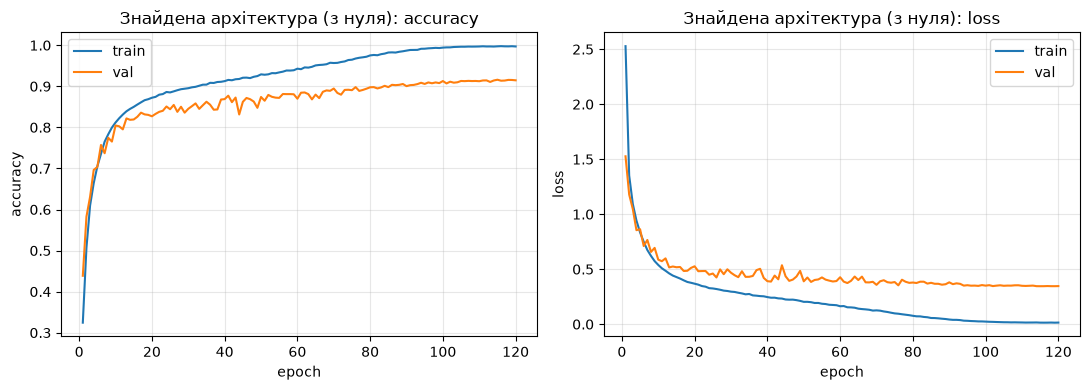

In [5]:
plots.plot_history(retrain["best"]["history"], title="Знайдена архітектура (з нуля)")
plt.show()

## 6. Бонус — наскільки інформативний one-shot proxy?

На питання зі звіту «how informative was the one-shot proxy?» відповідаємо **числом**,
а не відчуттям. Беремо топ-8 архітектур за proxy, тренуємо
кожну **коротко з нуля** (15 епох) і міряємо, наскільки
proxy-ранжування збігається з ранжуванням «справжнього» короткого навчання —
через Kendall τ і Spearman ρ.

**Результат: Kendall τ = 0.11, Spearman ρ = 0.19** — слабка додатна
кореляція. Причина видно з чисел: серед топ-8 proxy-точності
лежать у вузькому діапазоні 0.3 п.п. (усі ~73.40%),
тоді як справжні короткі — у 4.1 п.п. Тобто під спільними вагами
найкращі архітектури **майже нерозрізнимі**, і тонке ранжування між ними — це шум.

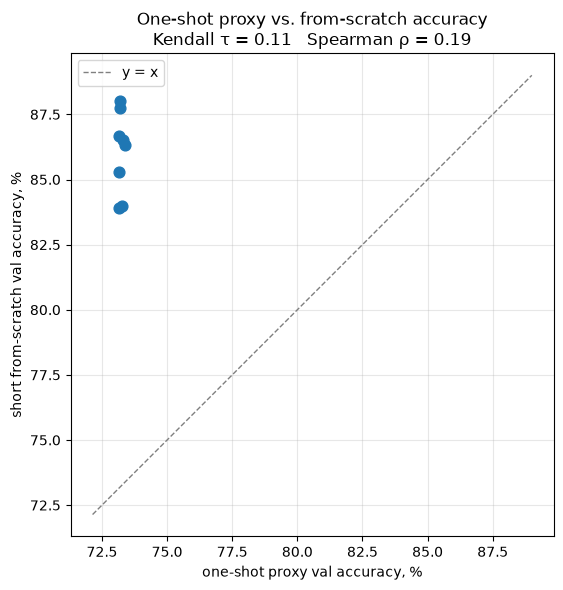

proxy=0.7340  short=0.8632  0.74M  conv3x3/mbconv/conv3x3/mbconv w1.0 relu6
proxy=0.7330  short=0.8652  0.52M  conv3x3/mbconv/conv3x3/conv3x3 w0.75 relu6
proxy=0.7328  short=0.8400  0.93M  conv3x3/mbconv/mbconv/mbconv w1.25 relu6
proxy=0.7320  short=0.8776  0.93M  conv3x3/mbconv/conv3x3/conv3x3 w1.0 relu
proxy=0.7318  short=0.8800  0.93M  conv3x3/mbconv/conv3x3/conv3x3 w1.0 relu6
proxy=0.7314  short=0.8666  0.74M  conv3x3/mbconv/conv3x3/mbconv w1.0 gelu
proxy=0.7314  short=0.8392  0.60M  conv3x3/mbconv/mbconv/mbconv w1.0 leakyrelu
proxy=0.7314  short=0.8528  1.16M  conv3x3/mbconv/conv3x3/mbconv w1.25 relu6


In [6]:
proxy = [r["proxy_val_acc"] for r in corr["rows"]]
real  = [r["short_val_acc"] for r in corr["rows"]]
plots.plot_proxy_correlation(proxy, real, tau=corr["kendall_tau"], rho=corr["spearman_rho"])
plt.show()
for r in corr["rows"]:
    print(f'proxy={r["proxy_val_acc"]:.4f}  short={r["short_val_acc"]:.4f}  '
          f'{r["params"]/1e6:.2f}M  {"/".join(r["arch"]["ops"])} w{r["arch"]["width"]} {r["arch"]["act"]}')

## 7. Висновки (звіт)

**Що спрацювало добре.**
- Пошук знайшов архітектуру **12.8× меншу** за VGG11 із практично тією ж
  точністю (90.69% vs 90.71%) — головна ціль NAS
  (краще співвідношення точність/розмір) досягнута.
- **Weight sharing зробив пошук дешевим:** одна supernet (100 епох)
  + 250 майже безкоштовних trial-ів замість 1620 повних
  тренувань. Оцінка одного кандидата — рекалібрація BN + один прохід по val.
- **TPE + proxy впевнено знаходять хороший регіон:** топ збігся на чіткий мотив
  (`conv3x3` на вході, `mbconv` в середині, повна ширина, ReLU6), а найгірші
  (усі-`dwsep`, 0.5×) відсіяні. Грубе ранжування — надійне.

**Що не спрацювало / вийшло не як очікувалось.**
- **Тонке ранжування proxy — слабке** (τ=0.11). Серед топ-архітектур spread
  proxy — лише 0.3 п.п., тож обрати «найкращу з найкращих» proxy не
  може; фінальний вибір усередині топу — майже випадковий (нам пощастило, що обрана
  архітектура добре до-тренувалась). Це відома вада one-shot: co-adaptation спільних
  ваг вирівнює сильних кандидатів.
- **Разрив proxy↔реальне навчання великий за абсолютом** (proxy ~73% vs справжні
  84–91%): спільні ваги недо-треновані для кожного окремого шляху. Для *ранжування*
  це прийнятно, для *абсолютної* оцінки — ні.

**Наскільки інформативний one-shot proxy?** Двошарова відповідь: **для грубого
відсіву — дуже** (безпомилково відкидає слабкі операції/ширини й знаходить хорошу
зону), **для тонкого вибору переможця — слабко** (τ=0.11). На практиці proxy варто
використовувати як **фільтр** (звузити 1620 → десяток кандидатів), а фінал вирішувати
коротким справжнім до-навчанням — рівно як ми зробили в бонусі.

**Як покращити результати.**
- Тренувати supernet довше + **fairness-трюки** (FairNAS: кожен батч — усі операції по
  черзі) або sandwich-rule, щоб зменшити co-adaptation і підняти τ.
- Оцінювати кандидатів на **більшій підвибірці val** і з більшою BN-рекалібрацією
  (менше шуму в proxy).
- Розширити простір (глибина/kernel size/окремий stride) — зараз макро-скелет
  фіксований, тож виграш обмежений.
- Багато **seed-ів** і mean±std (усі числа тут — single-seed) для статистично
  надійних висновків.

## 8. Як ми це зробили / що пробували

- **Реюз, а не переписування.** Supernet — це пряме розширення `ElasticVGG11` з
  бонусу ДЗ3: той самий slimmable-зріз `W[:out, :in]` і та сама ідея BN-рекалібрації,
  лише додано вибір **операції** на стадію. `data`/`engine`/`model`/`utils` — без змін
  з ДЗ1–ДЗ3.
- **Чесний підрахунок параметрів.** Кількість параметрів рахуємо не аналітичною
  формулою, а **побудовою** реальної `StandaloneNet` — і тестом звіряємо, що зрізи ваг
  supernet мають **точно ті самі форми**, що й standalone-архітектура. Тобто «шукали
  одну мережу, а тренуємо іншу» тут неможливо за побудовою.
- **Fair baseline.** Порівнюємо не лише з VGG11, а й з in-space default при
  **ідентичному** рецепті тренування — інакше виграш можна було б списати на кращий
  розклад/епохи, а не на архітектуру.
- **Дисципліна даних.** Увесь пошук і кожне проміжне число — на **validation**; test
  чіпаємо рівно раз на фінальну модель (best / default / baseline). `inference_mode`
  в оцінці.
- **На чому спіткнулись.** (1) BN у one-shot: без рекалібрації активного шляху
  proxy-точність — сміття (running stats змішані по всіх ширинах); рекалібрація на
  ~64 батчах це лікує. (2) Слабка τ спочатку виглядала як баг, але
  це реальна властивість — топ-кандидати нерозрізнимі під спільними вагами; ми лишили
  це число як є, а не «покращили» його підбором. (3) Числа — single-seed: позначено
  скрізь.

## 9. Джерела

- Bergstra, Bardenet, Bengio, Kégl. *Algorithms for Hyper-Parameter Optimization.*
  NeurIPS 2011. (TPE — алгоритм, який використовує Hyperopt.)
- Bergstra, Yamins, Cox. *Hyperopt: A Python Library for Optimizing Hyperparameters.*
  SciPy 2013. — <https://github.com/hyperopt/hyperopt>
- Guo et al. *Single Path One-Shot Neural Architecture Search with Uniform Sampling.*
  ECCV 2020 (arXiv:1904.00420). — схема тренування supernet.
- Howard et al. *MobileNets.* 2017 (depthwise-separable); Sandler et al.
  *MobileNetV2: Inverted Residuals and Linear Bottlenecks.* CVPR 2018 — операції блоків.
- Yu, Huang. *Universally Slimmable Networks* / *Slimmable Neural Networks.* ICLR 2019 —
  ідея спільних ваг за шириною + per-width BN (яку ми реюзаємо з бонусу ДЗ3).